<a href="https://colab.research.google.com/github/toshi039a/customer-churn-prediction/blob/main/%E9%9B%A2%E8%84%B1%E4%BA%88%E6%B8%ACPF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EC顧客データを用いた離脱予測モデル構築

## 1. 概要とデータ読み込み

本分析では、Kaggleの「Ecommerce Customer Churn Analysis and Prediction」データセットを使用する。

本データは、ECサービスにおける顧客属性・利用状況・購買行動に関するデータであり、顧客が離脱するかどうかを予測することを目的とする。

顧客離脱予測は、既存顧客の維持・売上の機会損失防止・マーケティング施策の最適化において重要な分析テーマである。  
離脱リスクの高い顧客を事前に把握できれば、クーポン配布、サポート強化、利用促進施策などの打ち手につなげることができる。

なお、本データセットでは `Churn` は顧客離脱フラグとして提供されているが、離脱の具体的な定義は明記されていない。  
そのため、本分析では `Churn=1` を「ECサービスから離脱したと判定された顧客」、`Churn=0` を「継続顧客」として扱う。

本Notebookでは、以下の流れで離脱予測モデルを構築する。

1. 概要とデータ読み込み
2. 探索的データ分析（EDA）
3. 前処理と特徴量整理
4. モデリング・評価
5. ハイパーパラメータ調整
6. 閾値調整
7. モデル解釈
8. 施策提案
9. まとめ

### 1.1 データ構造の確認

まずは、データの行数・列数・カラムの型、欠損値の有無を確認する。

本データは顧客単位のデータであり、1行が1顧客を表す。  
目的変数は `Churn` であり、その他のカラムには顧客属性・利用状況・購買行動等に関する情報が含まれている。

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Google driveに格納したデータを読み込む
# データは以下から取得可能である。
# https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/離脱予測PF/E Commerce Dataset.xlsx'

df = pd.read_excel(file_path, sheet_name='E Comm')
data_dict = pd.read_excel(file_path, sheet_name='Data Dict')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

データは5,630行・20列で構成されている。  
数値変数とカテゴリ変数が混在しており、一部の数値変数には欠損値が存在する。

特に、以下のようなカラムに欠損値が確認される。

- `Tenure`
- `WarehouseToHome`
- `HourSpendOnApp`
- `OrderAmountHikeFromlastYear`
- `CouponUsed`
- `OrderCount`
- `DaySinceLastOrder`

これらの欠損値については、後続の前処理で適切に処理する。

### 1.2 カラム定義の確認

`Data Dict` シートには、各カラムの説明が記載されている。  
EDAやモデル解釈を行う前に、各変数の意味を確認する。

In [191]:
pd.set_option('display.max_colwidth', None)

data_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or website


本分析で特に重要と思われる主なカラムは以下の通りである。

- `Churn`：顧客離脱フラグ
- `Tenure`：顧客の利用期間
- `SatisfactionScore`：満足度スコア
- `Complain`：クレーム有無
- `OrderCount`：直近月の注文回数
- `DaySinceLastOrder`：最終注文からの日数
- `CashbackAmount`：キャッシュバック金額

なお、`CustomerID` は顧客識別用のIDであり、予測に直接使用しない。

### 1.3 目的変数の確認

本分析の目的変数である `Churn` の分布を確認する。

離脱予測では、離脱顧客が継続顧客より少ないケースが多いため、まずはクラス比率を確認する。  

In [192]:
# 目的変数の件数確認
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [193]:
# 離脱率の確認
churn_rate = df['Churn'].mean()

print(f'離脱率: {churn_rate:.2%}')

離脱率: 16.84%


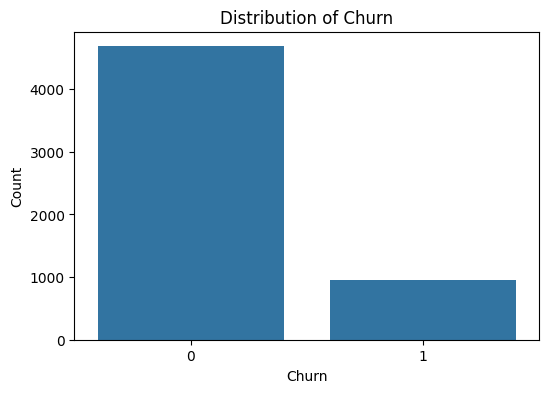

In [194]:
# Churnの分布を可視化
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- `Churn` の分布を確認したところ、離脱率は16.84%であり、継続顧客が多数を占めている。

- このことから、本データはクラス不均衡を含む二値分類問題であると考えられる。
- クラス不均衡がある場合、Accuracyだけでは少数派である離脱顧客の検出性能を適切に評価できないため、後続のモデル評価ではRecallやPrecision、PR-AUCなども重視する。

### 1.4 欠損値の詳細確認

`df.info()` により、一部の数値変数に欠損値が存在することが確認された。

ここでは各カラムの欠損数と欠損率を確認し、後続の前処理方針を検討する。

In [195]:
# 欠損数と欠損率を確認
missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_rate': df.isna().mean()
}).sort_values('missing_count', ascending=False)

# 欠損値があるカラムのみ表示
missing_df = missing_df[missing_df['missing_count'] > 0].copy()
missing_df

,missing_count,missing_rate
DaySinceLastOrder,307,0.054529
OrderAmountHikeFromlastYear,265,0.047069
Tenure,264,0.046892
OrderCount,258,0.045826
CouponUsed,256,0.045471
HourSpendOnApp,255,0.045293
WarehouseToHome,251,0.044583


- 欠損値を確認したところ、7つの数値変数に欠損が存在していることが分かった。
- 最も欠損が多い `DaySinceLastOrder` でも欠損率は5.45%であり、全体として欠損率は高くない。
- 欠損率が極端に高いカラムはないため、後続の前処理ではカラム削除ではなく中央値での補完によって対応する方針とする。

### 1.5 数値変数・カテゴリ変数の整理

モデル構築に向けて、数値変数とカテゴリ変数を整理する。

In [196]:
# 数値変数の抽出
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['CustomerID',
 'Churn',
 'Tenure',
 'CityTier',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'SatisfactionScore',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

In [197]:
# 文字列型カテゴリ変数の抽出
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

cat_cols

['PreferredLoginDevice',
 'PreferredPaymentMode',
 'Gender',
 'PreferedOrderCat',
 'MaritalStatus']

In [198]:
# 文字列型カテゴリ変数のユニーク数確認
df[cat_cols].nunique()

,0
PreferredLoginDevice,3
PreferredPaymentMode,7
Gender,2
PreferedOrderCat,6
MaritalStatus,3


In [199]:
# 各文字列型カテゴリ変数の値を確認
for col in cat_cols:
    print(f'【{col}】')
    print(df[col].value_counts(dropna=False))
    print('-' * 50)

【PreferredLoginDevice】
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
--------------------------------------------------
【PreferredPaymentMode】
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
--------------------------------------------------
【Gender】
Gender
Male      3384
Female    2246
Name: count, dtype: int64
--------------------------------------------------
【PreferedOrderCat】
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
--------------------------------------------------
【MaritalStatus】
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64
---------------

- 文字列型のカテゴリ変数として、ログイン端末、支払い方法、性別、主な注文カテゴリ、婚姻状況が含まれていることを確認した。
- これらのカテゴリ変数はいずれもユニーク数が多すぎず、後続の前処理ではOne-Hot Encodingで扱いやすい構成である。
- `SatisfactionScore` や `CityTier` は数値型として読み込まれているが、連続量というよりも評価スコアや都市階層を表す変数であり、カテゴリ変数に近い側面があるため、後続の前処理ではカテゴリ変数として扱う。
- `PreferredLoginDevice` では `Mobile Phone` と `Phone`、`PreferredPaymentMode` では `Credit Card` と `CC`、`COD` と `Cash on Delivery` のように、意味が近いと思われるカテゴリが存在している。
- ただし、本データセット上でこれらが完全に同一カテゴリであるとは明記されていないため、本分析では元データのカテゴリを大きく加工せず、前処理でエンコーディングを行う方針とする。
- 実務では、これらが同一カテゴリかどうかをデータ定義や業務担当者への確認によって判断し、必要に応じて表記ゆれの統一を行う。
- `CustomerID` は顧客識別用のIDであり、予測に直接使用しない。
- `Churn` は目的変数であるため、説明変数からは除外する。

## 2. 探索的データ分析（EDA）

ここでは、目的変数である `Churn` と各説明変数の関係を確認する。

特に、以下の観点から離脱傾向を把握する。

1. 利用期間と離脱率の関係
2. 満足度スコアと離脱率の関係
3. クレーム有無と離脱率の関係
4. 注文回数と離脱率の関係
5. 最終注文からの日数と離脱率の関係
6. カテゴリ変数ごとの離脱率
7. 数値変数同士の相関

EDAを通じてどのような顧客が離脱しやすい傾向にあるかを把握し、後続のモデル構築や施策提案につなげる。

### 2.1 利用期間と離脱率の関係

顧客の利用期間を表す `Tenure` と離脱率の関係を確認する。

一般的に、利用期間が短い顧客はサービスへの定着度が低く、離脱しやすい可能性がある。  
一方で、利用期間が長い顧客は継続利用の傾向が強いと考えられる。

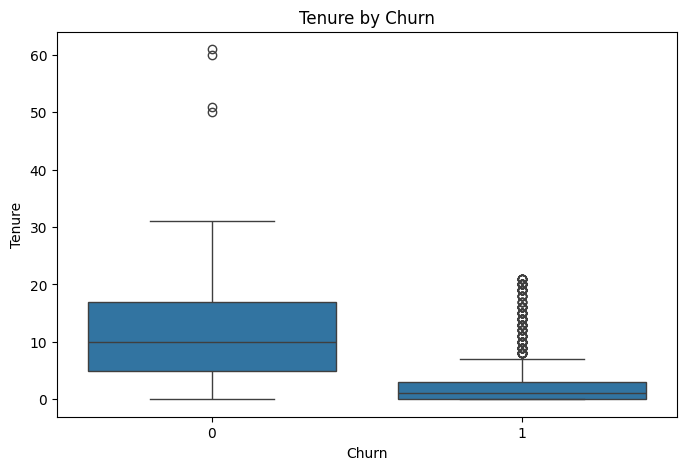

In [200]:
# Churn別にTenureの分布を確認
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='Tenure')
plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

In [201]:
# Tenureを各区間に分ける
df['Tenure_bin'] = pd.cut(
    df['Tenure'],
    bins=[0, 3, 6, 12, 24, np.inf],
    labels=['0-3', '4-6', '7-12', '13-24', '25+'],
    include_lowest=True
)

# Tenure区間ごとの離脱率と件数を集計
tenure_churn = df.groupby('Tenure_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

tenure_churn

,Tenure_bin,churn_rate,count
0,0-3,0.418590,1560
1,4-6,0.074576,590
2,7-12,0.056818,1320
3,13-24,0.064758,1467
4,25+,0.000000,429


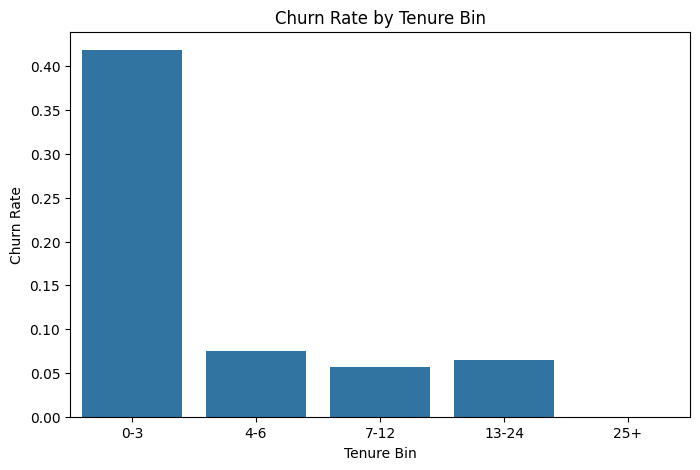

In [202]:
# 各Tenure区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=tenure_churn, x='Tenure_bin', y='churn_rate')
plt.title('Churn Rate by Tenure Bin')
plt.xlabel('Tenure Bin')
plt.ylabel('Churn Rate')
plt.show()

- `Tenure` を区間ごとに分けて離脱率を確認した。
- 利用期間が `0-3` の顧客では離脱率が約41.9%と高く、利用開始初期の顧客ほど離脱しやすい傾向が見られる。
- 一方で、`4-6` 以降の区間では離脱率が大きく低下しており、一定期間利用を継続した顧客は離脱しにくくなる傾向がある。
- `25+` の区間では、このデータ上では離脱率が0%となっている。
- この結果から、`Tenure` は離脱予測において重要な特徴量となる可能性がある。

### 2.2 満足度スコアと離脱率の関係

サービス評価に関するスコアである `SatisfactionScore` と離脱率の関係を確認する。

In [203]:
# SatisfactionScoreごとの離脱率と件数を集計
satisfaction_churn = df.groupby('SatisfactionScore').agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

satisfaction_churn

,SatisfactionScore,churn_rate,count
0,1,0.115120,1164
1,2,0.126280,586
2,3,0.171967,1698
3,4,0.171322,1074
4,5,0.238267,1108


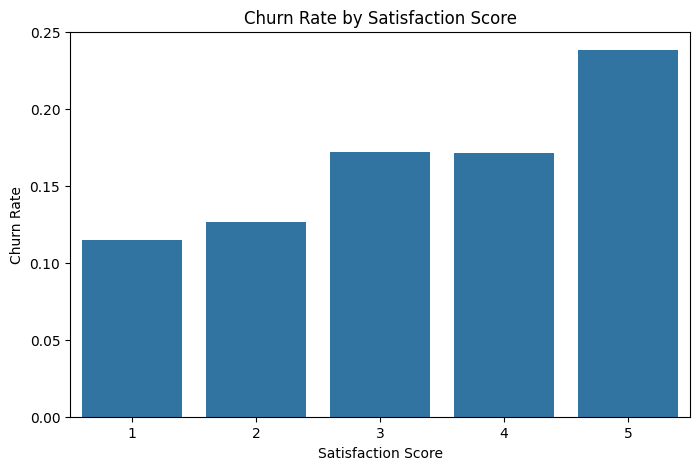

In [204]:
# SatisfactionScoreごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=satisfaction_churn, x='SatisfactionScore', y='churn_rate')
plt.title('Churn Rate by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Churn Rate')
plt.show()

- `SatisfactionScore` ごとの離脱率を確認したところ、スコアによって離脱率に差が見られた。
- 本データセットでは `SatisfactionScore` のスコアの向きが明記されていないため、値が高いほど満足度が高い、または低いとは断定しない。
- 一方で、`SatisfactionScore=5` の顧客では離脱率が高くなっており、離脱予測において有用な特徴量となる可能性がある。

### 2.3 クレーム有無と離脱率の関係

クレーム有無を表す `Complain` と離脱率の関係を確認する。

クレームがある顧客は、サービス体験に不満を持っている可能性があり、離脱リスクが高いと考えられる。

In [205]:
# Complainごとの離脱率と件数を集計
complain_churn = df.groupby('Complain').agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

complain_churn

,Complain,churn_rate,count
0,0,0.109290,4026
1,1,0.316708,1604


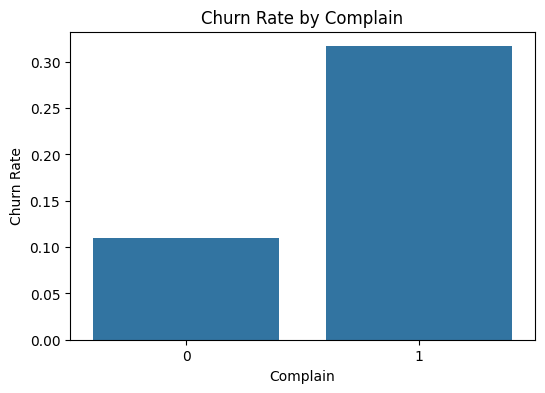

In [206]:
# Complainごとの離脱率を可視化
plt.figure(figsize=(6, 4))
sns.barplot(data=complain_churn, x='Complain', y='churn_rate')
plt.title('Churn Rate by Complain')
plt.xlabel('Complain')
plt.ylabel('Churn Rate')
plt.show()

- `Complain` ごとの離脱率を確認したところ、クレームなしの顧客の離脱率は約10.9%、クレームありの顧客の離脱率は約31.7%と、クレームありの顧客はクレームなしの顧客よりも離脱率が高い傾向が見られた。
- このことから、クレーム有無は離脱と強く関係している可能性がある。

### 2.4 注文回数と離脱率の関係

顧客の購買頻度を表す `OrderCount` と離脱率の関係を確認する。

一般的には、注文回数が少ない顧客ほどサービス利用が定着しておらず、離脱しやすい可能性がある。  
ここでは、注文回数を区間に分け、各区間ごとの離脱率を確認する。

In [207]:
# OrderCountを区間に分ける
df['OrderCount_bin'] = pd.cut(
    df['OrderCount'],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=['1', '2-3', '4-5', '6-10', '11+'],
    include_lowest=True
)

# OrderCount区間ごとの離脱率と件数を集計
order_count_bin_churn = df.groupby('OrderCount_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

order_count_bin_churn

,OrderCount_bin,churn_rate,count
0,1,0.180468,1751
1,2-3,0.182805,2396
2,4-5,0.109091,385
3,6-10,0.172920,613
4,11+,0.123348,227


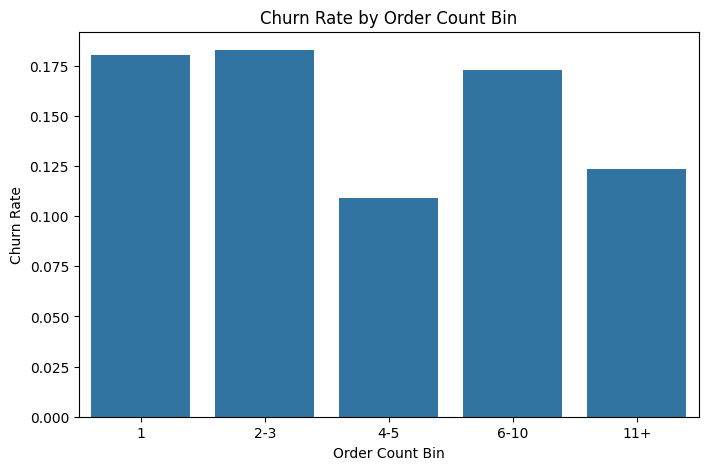

In [208]:
# OrderCount区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=order_count_bin_churn, x='OrderCount_bin', y='churn_rate')
plt.title('Churn Rate by Order Count Bin')
plt.xlabel('Order Count Bin')
plt.ylabel('Churn Rate')
plt.show()

- `OrderCount` を区間ごとに分けて離脱率を確認した。
- 注文回数が少ない顧客ほど離脱率が高い、という単純な傾向は見られなかった。
- 一方で、注文回数の区間ごとに離脱率には一定の差が見られる。
- 特に `1` や `2-3` の低頻度注文層では、離脱率が約18%前後となっている。
- ただし、注文回数が多い区間でも離脱率が高い箇所があり、`OrderCount` 単独で離脱傾向を説明するのは難しいと考えられる。
- このことから、`OrderCount` は他の特徴量と組み合わせて利用することで有用になる可能性がある。

### 2.5 最終注文からの日数と離脱率の関係

最終注文からの日数を表す `DaySinceLastOrder` と離脱率の関係を確認する。

一般的には、最終注文から日数が経過している顧客ほどサービス利用頻度が低下しており、離脱リスクが高い可能性がある。  
ここでは、最終注文からの日数を区間に分け、各区間ごとの離脱率を確認する。

In [209]:
# DaySinceLastOrderを区間に分ける
df['DaySinceLastOrder_bin'] = pd.cut(
    df['DaySinceLastOrder'],
    bins=[0, 3, 7, 14, np.inf],
    labels=['0-3', '4-7', '8-14', '15+'],
    include_lowest=True
)

# DaySinceLastOrder区間ごとの離脱率と件数を集計
last_order_churn = df.groupby('DaySinceLastOrder_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

last_order_churn

,DaySinceLastOrder_bin,churn_rate,count
0,0-3,0.215560,2802
1,4-7,0.136998,1219
2,8-14,0.095161,1240
3,15+,0.080645,62


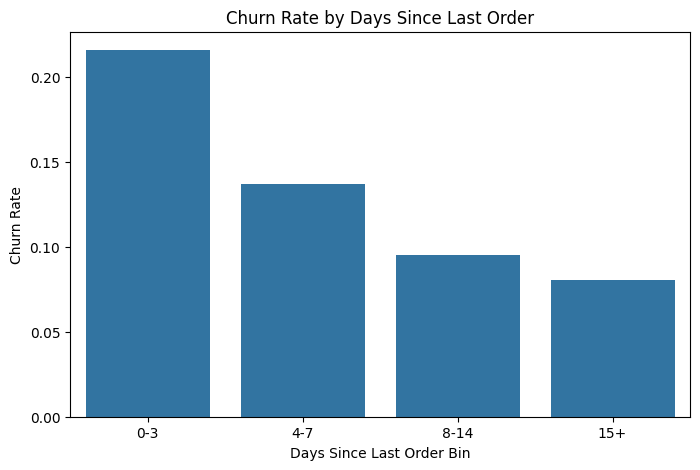

In [210]:
# DaySinceLastOrder区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=last_order_churn, x='DaySinceLastOrder_bin', y='churn_rate')
plt.title('Churn Rate by Days Since Last Order')
plt.xlabel('Days Since Last Order Bin')
plt.ylabel('Churn Rate')
plt.show()

- `DaySinceLastOrder` を区間ごとに分けて離脱率を確認した。
- 一般的には、最終注文から日数が経過している顧客ほど離脱リスクが高いと考えられる。
- しかし、本データでは `0-3` の区間で離脱率が最も高く、日数が長いほど離脱率が高くなるという単純な傾向は見られなかった。
- この結果は直感と異なるが、`DaySinceLastOrder` は単独で離脱を説明するというより、`Tenure` や `Complain`、`OrderCount` など他の特徴量と組み合わせて解釈する必要があると考えられる。

### 2.6 カテゴリ変数ごとの離脱率

カテゴリ変数ごとに離脱率を確認する。

ログイン端末、支払い方法、性別、主な注文カテゴリ、婚姻状況などのカテゴリによって、離脱率に違いがあるかを確認する。

,PreferredLoginDevice,churn_rate,count
0,Phone,0.224208,1231
1,Computer,0.198286,1634
2,Mobile Phone,0.125859,2765


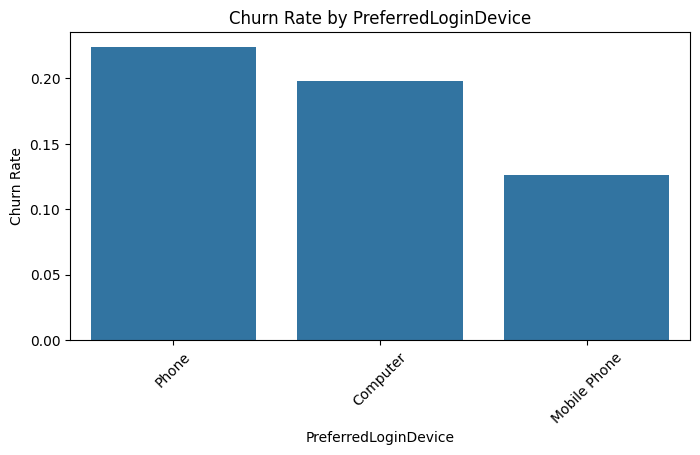

,PreferredPaymentMode,churn_rate,count
0,COD,0.287671,365
1,E wallet,0.228013,614
2,CC,0.216117,273
3,UPI,0.173913,414
4,Cash on Delivery,0.154362,149
5,Debit Card,0.153846,2314
6,Credit Card,0.128581,1501


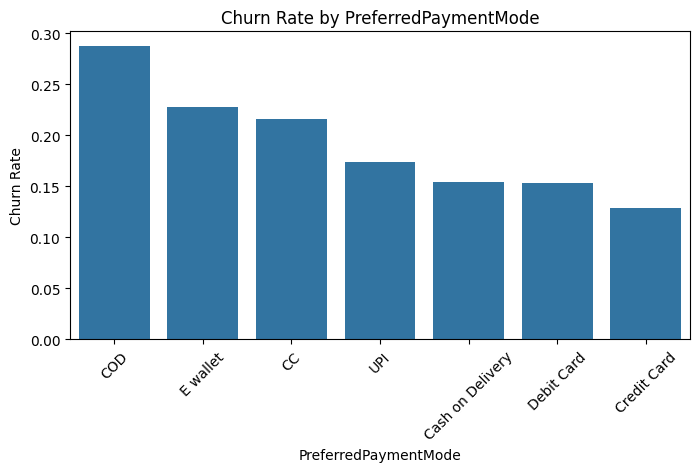

,Gender,churn_rate,count
0,Male,0.177305,3384
1,Female,0.154942,2246


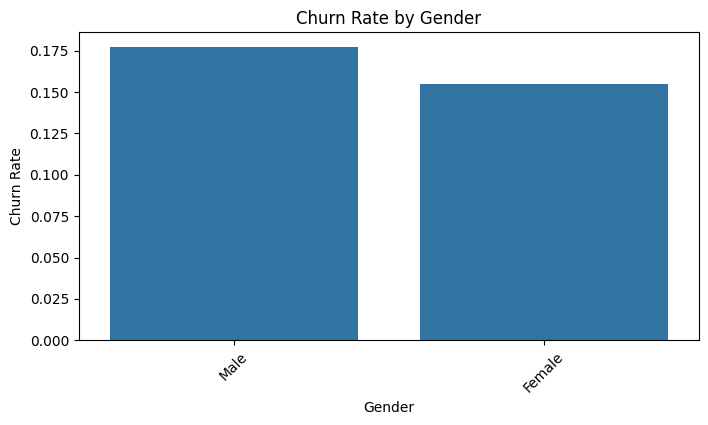

,PreferedOrderCat,churn_rate,count
0,Mobile Phone,0.275374,1271
1,Mobile,0.271941,809
2,Fashion,0.154964,826
3,Laptop & Accessory,0.102439,2050
4,Others,0.075758,264
5,Grocery,0.048780,410


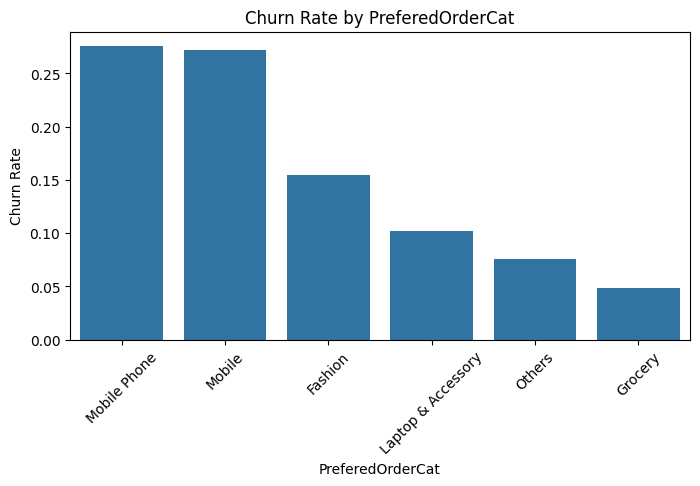

,MaritalStatus,churn_rate,count
0,Single,0.267261,1796
1,Divorced,0.146226,848
2,Married,0.115204,2986


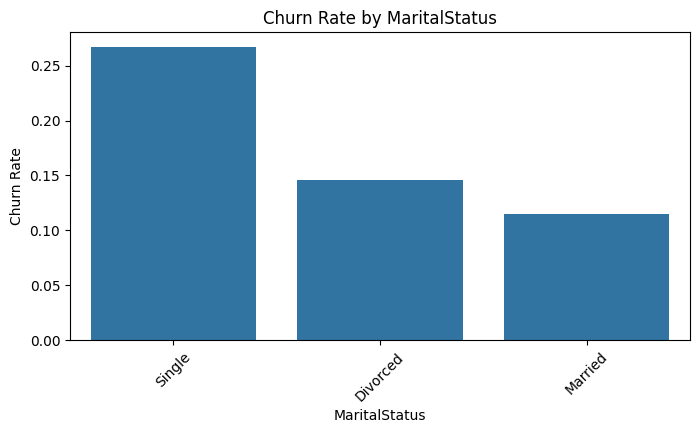

In [211]:
# カテゴリ変数ごとの離脱率と件数を確認
for col in cat_cols:
    churn_by_cat = df.groupby(col).agg(
        churn_rate=('Churn', 'mean'),
        count=('Churn', 'count')
    ).sort_values('churn_rate', ascending=False).reset_index()

    display(churn_by_cat)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=churn_by_cat, x=col, y='churn_rate')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45)
    plt.show()

- カテゴリ変数ごとの離脱率を確認したところ、カテゴリ毎で離脱率に差が見られた。
- `PreferredLoginDevice` では、`Phone` や `Computer` の離脱率が相対的に高く、`Mobile Phone` は低い傾向が見られた。
- `PreferredPaymentMode` では、`COD`、`E wallet`、`CC` の離脱率が相対的に高く、支払い方法によって離脱傾向に差がある可能性がある。
- `Gender` では、男性の離脱率が女性よりやや高いが、差は大きくない結果となった。
- `PreferedOrderCat` では、`Mobile Phone` や `Mobile` の離脱率が高く、商品カテゴリによって離脱傾向に違いが見られた。
- `MaritalStatus` では、`Single` の離脱率が最も高く、`Married` の離脱率が低い傾向が見られた。
- ただし、カテゴリごとに件数が異なるため、離脱率だけでなく母数も確認しながら解釈する必要がある。
- 前述の通り、`PreferredPaymentMode` の `CC` と `Credit Card`、`COD` と `Cash on Delivery` など、意味が近い可能性のあるカテゴリも存在するため、実務ではデータ定義を確認したうえで表記ゆれの統一を検討する。
- 後続の前処理では、これらのカテゴリ変数をOne-Hot Encodingし、モデルに利用する。

### 2.7 数値変数同士の相関

数値変数同士の相関を確認する。

相関を確認することで、目的変数である `Churn` と関係がありそうな変数や、説明変数同士で強く関連している変数を把握する。


In [212]:
# CustomerIDは識別用IDのため、相関分析から除外
corr_cols = [col for col in num_cols if col != 'CustomerID']

# 数値変数同士の相関を計算
corr = df[corr_cols].corr()

corr

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
Churn,1.000000,-0.349408,0.084703,0.076630,0.018675,0.107939,0.105481,0.043931,0.250188,-0.010058,-0.008264,-0.028697,-0.160757,-0.154118
Tenure,-0.349408,1.000000,-0.060688,-0.018218,-0.021226,-0.023983,-0.013903,0.237666,-0.021268,0.005825,0.129035,0.186403,0.184552,0.476380
CityTier,0.084703,-0.060688,1.000000,0.010624,-0.009150,0.027934,-0.011554,-0.029440,0.003375,-0.031408,0.021456,0.033388,0.017525,0.055746
WarehouseToHome,0.076630,-0.018218,0.010624,1.000000,0.060990,0.019071,0.007722,-0.011020,0.028696,0.038795,-0.003935,0.002681,0.017829,-0.009200
HourSpendOnApp,0.018675,-0.021226,-0.009150,0.060990,1.000000,0.316800,0.031858,0.145126,0.006976,0.106843,0.191528,0.109575,0.075716,0.121490
NumberOfDeviceRegistered,0.107939,-0.023983,0.027934,0.019071,0.316800,1.000000,-0.017228,0.084997,0.003407,0.069475,0.151685,0.103464,0.018208,0.137183
SatisfactionScore,0.105481,-0.013903,-0.011554,0.007722,0.031858,-0.017228,1.000000,0.053583,-0.031115,-0.027730,0.017936,0.019764,0.032082,0.003473
NumberOfAddress,0.043931,0.237666,-0.029440,-0.011020,0.145126,0.084997,0.053583,1.000000,-0.026399,0.015533,0.042120,-0.007609,-0.064847,0.186688
Complain,0.250188,-0.021268,0.003375,0.028696,0.006976,0.003407,-0.031115,-0.026399,1.000000,-0.004529,-0.008174,-0.019307,-0.043546,0.000525
OrderAmountHikeFromlastYear,-0.010058,0.005825,-0.031408,0.038795,0.106843,0.069475,-0.027730,0.015533,-0.004529,1.000000,0.033201,0.023101,0.006003,0.017869


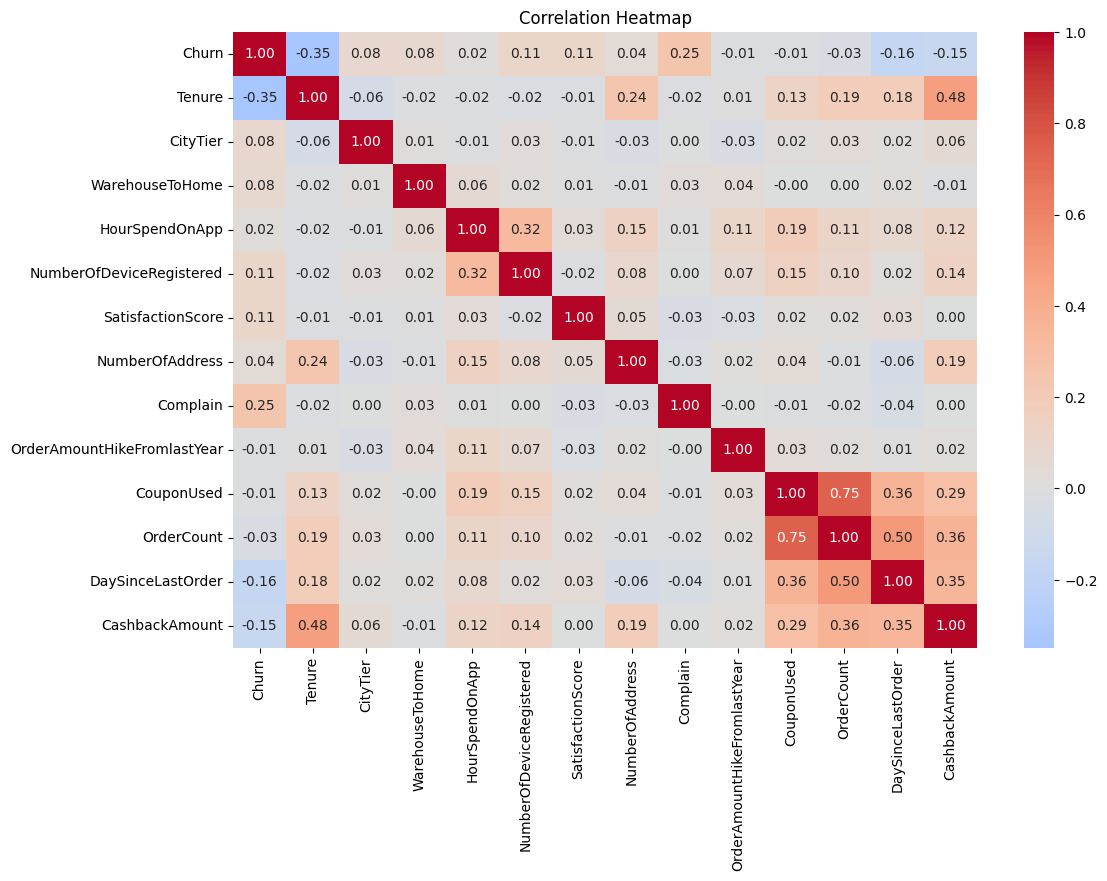

In [213]:
# 相関係数をヒートマップで可視化
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### 2.8 EDAまとめ

本章では、顧客属性・利用状況・購買行動と離脱率の関係を確認した。

主な結果は以下の通りである。

- `Tenure` を確認したところ、利用開始初期の顧客ほど離脱率が高い傾向が見られた。
- `SatisfactionScore` はスコアの向きが明記されていないものの、スコアによって離脱率に差が見られた。
- `Complain` では、クレームありの顧客はクレームなしの顧客と比較して離脱率が高い傾向が見られた。
- `OrderCount` や `DaySinceLastOrder` は、単独で離脱を説明するというより、他の特徴量と組み合わせて解釈する必要がある。
- カテゴリ変数ごとの離脱率にも差が見られ、顧客属性や利用状況によって離脱傾向が異なる可能性がある。
- 相関分析では、`Tenure` は `Churn` と負の相関、`Complain` は `Churn` と正の相関が見られた。
- 一方、相関が弱い特徴量であっても、非線形な関係や他の特徴量との組み合わせによって予測に寄与する可能性があるため、最終的な有用性はFeature ImportanceやSHAPで確認する。

## 3. 前処理と特徴量整理

ここからは、モデル構築に向けて前処理を行う。

本分析では、目的変数である `Churn` を予測対象とし、顧客属性・利用状況・購買行動に関する特徴量を用いて分類モデルを構築する。

後続のモデリングでは、解釈しやすい線形モデルである `Logistic Regression` と、表形式データに強い木系モデルである `LightGBM` を比較する。  
そのため、本章ではそれぞれのモデルで利用できるように前処理の流れを定義する。
前処理では、以下を実施する。

- 目的変数と説明変数の分割
- モデリングに使用しない列の除外
- 学習データ・検証データ・テストデータの分割
- 数値変数の欠損値補完・標準化
- カテゴリ変数の欠損値補完・エンコーディング

### 3.1 目的変数・説明変数の分割と学習データの作成

モデリングに向けて、目的変数 `Churn` と説明変数を分割する。

本分析では、データを以下の3つに分割する。

- 学習データ：モデル学習・ハイパーパラメータ調整に使用
- 検証データ：モデル比較および閾値調整に使用
- テストデータ：最後の最終評価に使用

モデル比較やハイパーパラメータ調整、閾値調整の段階でテストデータを使用すると、テストデータに合わせ込んだ評価になる可能性があるため、テストデータは最終評価用として保持し、モデル構築中には使用しない。

なお、`Churn` はクラス不均衡を含むため、各データで離脱率の比率が大きく変わらないよう、層化抽出を行う。

In [214]:
from sklearn.model_selection import train_test_split

# 目的変数
target = 'Churn'

# モデリングで使用しない列
drop_cols = [
    'CustomerID',
    'Tenure_bin',
    'OrderCount_bin',
    'DaySinceLastOrder_bin'
]

# 説明変数と目的変数に分割
X = df.drop(columns=[target] + drop_cols)
y = df[target]

# まず、最終評価用のテストデータを20%確保
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 残り80%を、学習データと検証データに分割
# 全体比では、学習データ64%、検証データ16%、テストデータ20%となる
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=0.2,
    random_state=42,
    stratify=y_train_valid
)

print('X_train      :', X_train.shape)
print('X_valid      :', X_valid.shape)
print('X_test       :', X_test.shape)
print('y_train      :', y_train.shape)
print('y_valid      :', y_valid.shape)
print('y_test       :', y_test.shape)

X_train      : (3603, 18)
X_valid      : (901, 18)
X_test       : (1126, 18)
y_train      : (3603,)
y_valid      : (901,)
y_test       : (1126,)


In [215]:
# 各データの離脱率を確認
print(f'全体の離脱率        : {y.mean():.2%}')
print(f'学習データの離脱率  : {y_train.mean():.2%}')
print(f'検証データの離脱率  : {y_valid.mean():.2%}')
print(f'テストデータの離脱率: {y_test.mean():.2%}')

全体の離脱率        : 16.84%
学習データの離脱率  : 16.82%
検証データの離脱率  : 16.87%
テストデータの離脱率: 16.87%


- 目的変数 `Churn` と説明変数を分割した。
- `CustomerID` は顧客識別用のIDであり、予測には直接使用しないため除外した。
- EDAで作成した `Tenure_bin`、`OrderCount_bin`、`DaySinceLastOrder_bin` は可視化用の派生列であり、元の特徴量と情報が重複するため除外した。
- 元データを学習データ3,603件、検証データ901件、テストデータ1,126件に分割した。
- 全体比では、学習データ64%、検証データ16%、テストデータ20%となる。
- 学習データはモデル学習とハイパーパラメータ調整、検証データはモデル比較と閾値調整、テストデータは最終評価に使用する。
- 全体の離脱率は16.84%、学習データの離脱率は16.82%、検証データの離脱率は16.87%、テストデータの離脱率は16.87%であった。
- `stratify` を指定したことで、各データにおける離脱率は全体の離脱率と近い比率を保ったまま分割できている。

### 3.2 数値変数・カテゴリ変数の整理

前処理を定義するため、説明変数を数値変数とカテゴリ変数に分ける。

まずは、`X_train` のデータ型をもとに数値変数とカテゴリ変数を抽出する。  
そのうえで、`SatisfactionScore` や `CityTier` は数値型として読み込まれているものの、連続量というより評価スコアや都市階層を表す変数であり、カテゴリ変数に近い側面があるため、本分析ではカテゴリ変数として扱う。

一方で、`Complain` は0/1で表現された二値フラグであるため、数値変数としてそのまま扱う。

In [216]:
# データ型をもとに数値変数・カテゴリ変数を抽出
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print('データ型ベースの数値変数')
print(num_cols)

print('\nデータ型ベースのカテゴリ変数')
print(cat_cols)

print(f'\nデータベース型の数値変数の数: {len(num_cols)}')
print(f'データベース型のカテゴリ変数の数: {len(cat_cols)}')

データ型ベースの数値変数
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

データ型ベースのカテゴリ変数
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

データベース型の数値変数の数: 13
データベース型のカテゴリ変数の数: 5


In [217]:
# 数値型として読み込まれているが、カテゴリ変数として扱うカラム
categorical_like_cols = ['SatisfactionScore', 'CityTier']

# モデリング用の数値変数
num_cols_model = [col for col in num_cols if col not in categorical_like_cols]

# モデリング用のカテゴリ変数
cat_cols_model = cat_cols + categorical_like_cols

print('モデリング用 数値変数')
print(num_cols_model)

print('\nモデリング用 カテゴリ変数')
print(cat_cols_model)

print(f'\nモデリング用 数値変数の数: {len(num_cols_model)}')
print(f'モデリング用 カテゴリ変数の数: {len(cat_cols_model)}')

モデリング用 数値変数
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

モデリング用 カテゴリ変数
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus', 'SatisfactionScore', 'CityTier']

モデリング用 数値変数の数: 11
モデリング用 カテゴリ変数の数: 7


- X_train を基準に、数値変数とカテゴリ変数を整理した。
- データ型ベースでは、数値変数が13個、カテゴリ変数が5個であることを確認した。
- `SatisfactionScore` や `CityTier` は数値型として読み込まれているが、連続量というより評価スコアや都市階層を表す変数であり、カテゴリ変数に近い側面がある。
- そのため、本分析では `SatisfactionScore` と `CityTier` をカテゴリ変数として扱い、One-Hot Encodingを行う。
- 最終的に、モデリング用の数値変数は11個、カテゴリ変数は7個となった。

### 3.3 前処理の定義

ここでは、`Logistic Regression` 用と `LightGBM` 用に、それぞれ前処理を定義する。

`Logistic Regression` は特徴量のスケールの影響を受けやすいため、数値変数には中央値補完に加えて標準化を行う。  
一方で、`LightGBM` は木系モデルであり特徴量のスケールの影響を受けにくいため、数値変数には中央値補完のみを行う。

カテゴリ変数については本データ上では欠損値は確認されていないが、前処理の汎用性を考慮し、両モデルとも最頻値補完を行ったうえでOne-Hot Encodingを適用する。

In [218]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Logistic Regression用：数値変数は中央値補完 + 標準化
numeric_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# LightGBM用：数値変数は中央値補完のみ
numeric_transformer_lgbm = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# カテゴリ変数：最頻値補完 + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Logistic Regression用の前処理
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lr, num_cols_model),
        ('cat', categorical_transformer, cat_cols_model)
    ]
)

# LightGBM用の前処理
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lgbm, num_cols_model),
        ('cat', categorical_transformer, cat_cols_model)
    ]
)

- `Logistic Regression` 用と `LightGBM` 用に、それぞれ前処理を定義した。
- `OneHotEncoder(handle_unknown='ignore')` を指定することで、検証データやテストデータに学習データには存在しないカテゴリが含まれていてもエラーにならないようにした。
- 後続のモデリングでは、これらの前処理と分類モデルを組み合わせて学習・評価を行う。

## 4. モデリング

ここからは、前処理と分類モデルを組み合わせて、顧客の離脱有無を予測するモデルを構築する。

本分析では、以下のモデルを比較する。

- ベースラインモデル
- Logistic Regression
- LightGBM

本データは離脱顧客が少ないクラス不均衡データであるため、Accuracyだけでなく、離脱顧客をどの程度検出できているかを表すRecallや、離脱と予測した顧客のうち実際に離脱している割合を表すPrecisionも確認する。

また、閾値に依存しない形でPrecisionとRecallのバランスを確認するため、PR-AUCも確認する。  
本分析では、PR-AUCに相当する指標として、scikit-learnの `average_precision_score` を用いる。

なお、モデル比較は検証データを用いて行い、テストデータは最終評価まで使用しない。

### 4.1 ベースラインモデル

まずは、すべての顧客を多数派クラスである `Churn=0` と予測するベースラインモデルを作成する。

本データでは継続顧客が多数を占めているため、単純に多数派クラスを予測するだけでもAccuracyは一定程度高くなる可能性がある。  
このベースラインと比較することで、後続のモデルが少数派である離脱顧客をどの程度検出できるかを確認する。

In [219]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix
)

# すべての顧客を継続顧客（Churn=0）と予測
baseline_pred = np.zeros_like(y_valid)

# PR-AUC計算用に、全員の離脱確率を0とする
baseline_proba = np.zeros_like(y_valid, dtype=float)

# 評価指標を計算
baseline_accuracy = accuracy_score(y_valid, baseline_pred)
baseline_precision = precision_score(y_valid, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_valid, baseline_pred)
baseline_pr_auc = average_precision_score(y_valid, baseline_proba)

print(f'Accuracy : {baseline_accuracy:.4f}')
print(f'Precision: {baseline_precision:.4f}')
print(f'Recall   : {baseline_recall:.4f}')
print(f'PR-AUC   : {baseline_pr_auc:.4f}')

Accuracy : 0.8313
Precision: 0.0000
Recall   : 0.0000
PR-AUC   : 0.1687


In [220]:
# 混同行列を確認
baseline_cm = confusion_matrix(y_valid, baseline_pred)

baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

baseline_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,749,0
Actual Churn=1,152,0


In [221]:
# ベースラインモデルの評価結果を保存
baseline_result = pd.DataFrame({
    'model': ['Baseline'],
    'accuracy': [baseline_accuracy],
    'precision': [baseline_precision],
    'recall': [baseline_recall],
    'pr_auc': [baseline_pr_auc]
})

baseline_result

,model,accuracy,precision,recall,pr_auc
0,Baseline,0.831299,0.0,0.0,0.168701


- ベースラインモデルとして、すべての顧客を多数派クラスである `Churn=0` と予測した。
- 検証データにおけるAccuracyは約83.1%と高くなっているが、継続顧客が多数を占めるクラス不均衡の影響によるものである。
- 一方で、PrecisionとRecallはいずれも0.0%であり、離脱顧客を一人も検出できていない。
- `Churn=1` と予測された顧客が存在しないため、Precisionは数学的には未定義となるが、本分析では `zero_division=0` を指定し、0として扱った。
- 混同行列においても、実際の離脱顧客152件はすべて `Churn=0` と予測されており、離脱顧客を検出できていない。
- 以上より、Accuracyは高く見えても、離脱顧客を検出できているとは限らないことが分かる。


### 4.2 Logistic Regression

次に、解釈しやすい線形モデルである `Logistic Regression` を構築する。

`Logistic Regression` は、特徴量と目的変数の関係を係数として確認できるため、比較的解釈しやすいモデルである。

本データでは離脱顧客が少ないため、`class_weight='balanced'` を指定し、少数派である離脱顧客の誤分類を相対的に重く扱うことで、離脱顧客を検出しやすくする。

In [222]:
from sklearn.linear_model import LogisticRegression

# Logistic Regressionモデルを定義
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# 前処理とモデルをPipeline化
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('model', lr_model)
])

# 学習
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus',
                                                   'SatisfactionScore',
                                                   'CityTier'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [223]:
# 検証データで予測ラベルと予測確率を取得
lr_pred = lr_pipeline.predict(X_valid)
lr_proba = lr_pipeline.predict_proba(X_valid)[:, 1]

# 評価指標を計算
lr_accuracy = accuracy_score(y_valid, lr_pred)
lr_precision = precision_score(y_valid, lr_pred, zero_division=0)
lr_recall = recall_score(y_valid, lr_pred)
lr_pr_auc = average_precision_score(y_valid, lr_proba)

print(f'Accuracy : {lr_accuracy:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'Recall   : {lr_recall:.4f}')
print(f'PR-AUC   : {lr_pr_auc:.4f}')

Accuracy : 0.8158
Precision: 0.4731
Recall   : 0.8092
PR-AUC   : 0.7326


In [224]:
# 混同行列を確認
lr_cm = confusion_matrix(y_valid, lr_pred)

lr_cm_df = pd.DataFrame(
    lr_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

lr_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,612,137
Actual Churn=1,29,123


In [225]:
# Logistic Regressionの評価結果を保存
lr_result = pd.DataFrame({
    'model': ['Logistic Regression'],
    'accuracy': [lr_accuracy],
    'precision': [lr_precision],
    'recall': [lr_recall],
    'pr_auc': [lr_pr_auc]
})

lr_result

,model,accuracy,precision,recall,pr_auc
0,Logistic Regression,0.81576,0.473077,0.809211,0.732616


- Logistic Regression を用いて離脱予測モデルを構築した。
- 検証データにおける評価結果は、Accuracyが約81.6%、Precisionが約47.3%、Recallが約80.9%、PR-AUCが約73.3%であった。
- ベースラインモデルでは離脱顧客を検出できなかった一方で、Logistic Regression では実際の離脱顧客152件のうち123件を正しく検出できた。
- 一方で、離脱と予測した260件のうち、実際に離脱した顧客は123件であり、137件は継続顧客であった。
- そのため、Recallは高い一方で、Precisionには改善余地がある。
- PR-AUCはベースラインモデルの約16.9%を大きく上回る約73.3%となっており、離脱顧客の検出性能は改善していると考えられる。

### 4.3 LightGBM

次に、表形式データに強い木系モデルである `LightGBM` を構築する。

`LightGBM` は、非線形な関係や特徴量同士の相互作用を捉えやすく、表形式データでよく用いられるモデルである。

ここでは、3章で作成した `LightGBM` 用の前処理とモデルをPipelineで結合し、学習データでモデルを学習する。

In [226]:
from lightgbm import LGBMClassifier

# LightGBMモデルを定義
lgbm_model = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

# 前処理とモデルをPipeline化
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('model', lgbm_model)
])

# 学習
lgbm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus',
                                                   'SatisfactionScore',
                                                   'CityTier'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', random_state=42,
                                verbose=-1))])

In [227]:
# 検証データで予測ラベルと予測確率を取得
lgbm_pred = lgbm_pipeline.predict(X_valid)
lgbm_proba = lgbm_pipeline.predict_proba(X_valid)[:, 1]

# 評価指標を計算
lgbm_accuracy = accuracy_score(y_valid, lgbm_pred)
lgbm_precision = precision_score(y_valid, lgbm_pred, zero_division=0)
lgbm_recall = recall_score(y_valid, lgbm_pred)
lgbm_pr_auc = average_precision_score(y_valid, lgbm_proba)

print(f'Accuracy : {lgbm_accuracy:.4f}')
print(f'Precision: {lgbm_precision:.4f}')
print(f'Recall   : {lgbm_recall:.4f}')
print(f'PR-AUC   : {lgbm_pr_auc:.4f}')

Accuracy : 0.9501
Precision: 0.8204
Recall   : 0.9013
PR-AUC   : 0.9412


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [228]:
# 混同行列を確認
lgbm_cm = confusion_matrix(y_valid, lgbm_pred)

lgbm_cm_df = pd.DataFrame(
    lgbm_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

lgbm_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,719,30
Actual Churn=1,15,137


In [229]:
# LightGBMの評価結果を保存
lgbm_result = pd.DataFrame({
    'model': ['LightGBM'],
    'accuracy': [lgbm_accuracy],
    'precision': [lgbm_precision],
    'recall': [lgbm_recall],
    'pr_auc': [lgbm_pr_auc]
})

lgbm_result

,model,accuracy,precision,recall,pr_auc
0,LightGBM,0.950055,0.820359,0.901316,0.941212


- LightGBMを用いて離脱予測モデルを構築した。
- 検証データでは、Accuracyが約95.0%、Precisionが約82.0%、Recallが約90.1%、PR-AUCが約94.1%となり、Logistic Regressionを上回る性能を示した。
- 実際の離脱顧客152件のうち137件を正しく検出できており、離脱防止施策の候補顧客を抽出する目的に適していると考えられる。

### 4.4 モデル比較

ここでは、ベースラインモデル、`Logistic Regression`、`LightGBM` の評価結果を比較する。

In [230]:
# 各モデルの評価結果を結合
model_results = pd.concat(
    [baseline_result, lr_result, lgbm_result],
    ignore_index=True
)
# 評価結果を小数第3位で表示
model_results.round(3)

,model,accuracy,precision,recall,pr_auc
0,Baseline,0.831,0.000,0.000,0.169
1,Logistic Regression,0.816,0.473,0.809,0.733
2,LightGBM,0.950,0.820,0.901,0.941


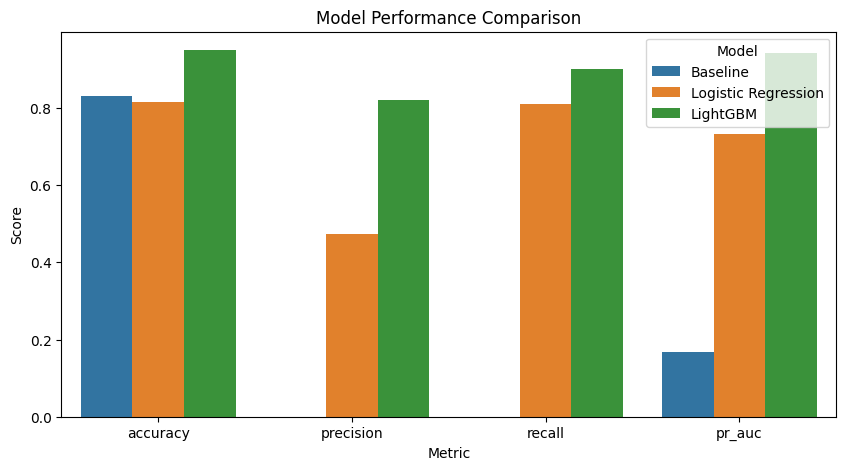

In [231]:
# モデルごとの評価指標を可視化
model_results_melted = model_results.melt(
    id_vars='model',
    value_vars=['accuracy', 'precision', 'recall', 'pr_auc'],
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=model_results_melted, x='metric', y='score', hue='model')
plt.title('Model Performance Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.legend(title='Model')
plt.show()

- 3モデルの評価結果を比較した。
- ベースラインモデルはAccuracyが約83.1%となったが、RecallとPrecisionは0.0%であり、離脱顧客を検出できていない。
- Logistic Regression は、Accuracyが約81.6%、Precisionが約47.3%、Recallが約80.9%、PR-AUCが約73.3%となった。
- Logistic Regression はベースラインモデルと比較して、離脱顧客を一定程度検出できている一方で、Precisionは約47.3%にとどまっており、離脱と予測した顧客の中に継続顧客も多く含まれている。
- LightGBM は、Accuracyが約95.0%、Precisionが約82.0%、Recallが約90.1%、PR-AUCが約94.1%となり、Logistic Regressionを大きく上回る性能を示した。
- 特にLightGBMは、RecallとPrecisionの両方が高く、離脱顧客の見逃しを抑えつつ、施策対象の精度も一定程度確保できている。
- 以上より、本分析では LightGBM を最終モデルとして採用し、後続のハイパーパラメータ調整や閾値調整を行う。

## 5. ハイパーパラメータ調整

4章のモデル比較では、`LightGBM` が最も高い予測性能を示した。

ここでは、最終モデルとして採用する `LightGBM` について、ハイパーパラメータ調整を行う。  
学習データ内で交差検証を行い、PR-AUCを評価指標として、より性能の高いパラメータを探索する。

なお、ハイパーパラメータ調整は学習データ内で行い、検証データはチューニング後モデルの性能確認および閾値調整に使用する。

### 5.1 LightGBMのハイパーパラメータ調整

本分析では、探索範囲を広げすぎず、代表的なパラメータに絞って `RandomizedSearchCV` による探索を行う。

交差検証には、目的変数のクラス比率を各分割で保つため、`StratifiedKFold` を用いる。

評価指標には、クラス不均衡データにおいて少数派クラスである離脱顧客の検出性能を評価しやすい、
PR-AUCに相当する `average_precision` を用いる。

In [232]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# LightGBMモデルを定義
lgbm_model_tuning = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

# 前処理とモデルをPipeline化
lgbm_pipeline_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('model', lgbm_model_tuning)
])

# 探索するハイパーパラメータ
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__num_leaves': [15, 31, 63],
    'model__max_depth': [-1, 3, 5, 7],
    'model__min_child_samples': [10, 20, 30, 50],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# 交差検証の設定
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RandomizedSearchCVで探索
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline_tuning,
    param_distributions=param_dist,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 学習データ内でハイパーパラメータ調整
lgbm_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['Tenure',
                                                                                'WarehouseToHome',
                                                                                'HourSpendOnApp',
                                                                                'NumberOfDeviceRegistered',
                                                                                'NumberOfAddress',
                                                                                'Complain',
                                                                                'OrderAmountHikeFromlastYe...
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [-1, 3, 5, 7],
                                        'model__min_child_samples': [10, 20, 30,
                                                                     50],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__num_leaves': [15, 31, 63],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [233]:
# 最良パラメータとCVスコアを確認
print('Best Parameters:')
print(lgbm_search.best_params_)

print(f"\nBest CV PR-AUC: {lgbm_search.best_score_:.4f}")

Best Parameters:
{'model__subsample': 0.7, 'model__num_leaves': 63, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': -1, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}

Best CV PR-AUC: 0.9245


In [234]:
# 最良モデルを取得
best_lgbm_pipeline = lgbm_search.best_estimator_

# 検証データで予測
best_lgbm_pred = best_lgbm_pipeline.predict(X_valid)
best_lgbm_proba = best_lgbm_pipeline.predict_proba(X_valid)[:, 1]

# 評価指標を計算
best_lgbm_accuracy = accuracy_score(y_valid, best_lgbm_pred)
best_lgbm_precision = precision_score(y_valid, best_lgbm_pred, zero_division=0)
best_lgbm_recall = recall_score(y_valid, best_lgbm_pred)
best_lgbm_pr_auc = average_precision_score(y_valid, best_lgbm_proba)

print(f'Accuracy : {best_lgbm_accuracy:.4f}')
print(f'Precision: {best_lgbm_precision:.4f}')
print(f'Recall   : {best_lgbm_recall:.4f}')
print(f'PR-AUC   : {best_lgbm_pr_auc:.4f}')

Accuracy : 0.9723
Precision: 0.9262
Recall   : 0.9079
PR-AUC   : 0.9682


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [235]:
# 混同行列を確認
best_lgbm_cm = confusion_matrix(y_valid, best_lgbm_pred)

best_lgbm_cm_df = pd.DataFrame(
    best_lgbm_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

best_lgbm_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,738,11
Actual Churn=1,14,138


In [236]:
# チューニング後LightGBMの評価結果を保存
best_lgbm_result = pd.DataFrame({
    'model': ['LightGBM Tuned'],
    'accuracy': [best_lgbm_accuracy],
    'precision': [best_lgbm_precision],
    'recall': [best_lgbm_recall],
    'pr_auc': [best_lgbm_pr_auc]
})

best_lgbm_result

,model,accuracy,precision,recall,pr_auc
0,LightGBM Tuned,0.972253,0.926174,0.907895,0.968214


### 5.2 チューニング前後の性能比較

ここでは、チューニング前後の `LightGBM` の評価結果を比較する。

In [237]:
# チューニング前後のLightGBMの評価結果を比較
tuning_comparison = pd.concat(
    [lgbm_result, best_lgbm_result],
    ignore_index=True
)

tuning_comparison.round(3)

,model,accuracy,precision,recall,pr_auc
0,LightGBM,0.950,0.820,0.901,0.941
1,LightGBM Tuned,0.972,0.926,0.908,0.968


- チューニング前後のLightGBMの評価結果を比較した。
- チューニング前のLightGBMは、Accuracyが約95.0%、Precisionが約82.0%、Recallが約90.1%、PR-AUCが約94.1%であった。
- チューニング後のLightGBMは、Accuracyが約97.2%、Precisionが約92.6%、Recallが約90.8%、PR-AUCが約96.8%となった。
- チューニングにより、Accuracy、Precision、Recall、PR-AUCはいずれも改善した。
- 特にPrecisionは約82.0%から約92.6%へ大きく改善しており、離脱リスクありと判定した顧客の精度が高まった。
- Recallも約90.1%から約90.8%へわずかに改善しており、離脱顧客の見逃しを抑える性能も維持できている。
- 以上より、以降の分析ではチューニング後のLightGBMを用いて、閾値調整・モデル解釈・施策提案を行う。

## 6. 閾値調整

前章まででは、チューニング後のLightGBMについてデフォルトの閾値0.5を用いて評価を行った。

しかし、分類モデルでは予測確率をどの閾値で0/1に変換するかによって、Precision・Recall・F1-scoreなどの評価指標が変化する。

特に離脱予測では、施策目的によって重視すべき指標が異なり、離脱しそうな顧客をできるだけ広く拾いたい場合はRecall、施策対象を確度の高い顧客に絞りたい場合はPrecision、見逃しと施策コストのバランスを取りたい場合はF1-scoreが重要になる。

なお、テストデータを使って閾値を選定すると、テストデータに合わせ込んだ評価になってしまう可能性がある。

そのため本章では、検証データを用いて閾値を選定し、最後に選定した閾値をテストデータへ適用して最終評価を行う。

### 6.1 閾値ごとの評価指標の確認

ここでは検証データを用いて、閾値ごとのAccuracy・Precision・Recall・F1-scoreを確認する。

あわせて、各閾値で離脱と判定される顧客数も確認し、後続の施策提案につなげる。

In [238]:
# 検証データに対する離脱確率を取得
valid_proba = best_lgbm_pipeline.predict_proba(X_valid)[:, 1]

valid_proba[:10]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([7.97283320e-05, 7.32381064e-06, 5.31667295e-07, 9.99902126e-01,
       2.34906535e-05, 1.19215213e-08, 1.45450847e-04, 5.94879988e-06,
       1.16706573e-04, 1.87968840e-04])

In [239]:
# 閾値ごとの評価指標を算出
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for threshold in thresholds:
    y_valid_pred_threshold = (valid_proba >= threshold).astype(int)

    threshold_results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_valid, y_valid_pred_threshold),
        'precision': precision_score(y_valid, y_valid_pred_threshold, zero_division=0),
        'recall': recall_score(y_valid, y_valid_pred_threshold),
        'f1': f1_score(y_valid, y_valid_pred_threshold),
        'predicted_churn_count': y_valid_pred_threshold.sum(),
        'predicted_churn_rate': y_valid_pred_threshold.mean()
    })

threshold_summary_df = pd.DataFrame(threshold_results)

threshold_summary_df

,threshold,accuracy,precision,recall,f1,predicted_churn_count,predicted_churn_rate
0,0.10,0.964484,0.870370,0.927632,0.898089,162,0.179800
1,0.15,0.965594,0.880503,0.921053,0.900322,159,0.176471
2,0.20,0.966704,0.886076,0.921053,0.903226,158,0.175361
3,0.25,0.967814,0.891720,0.921053,0.906149,157,0.174251
4,0.30,0.966704,0.896104,0.907895,0.901961,154,0.170921
5,0.35,0.968923,0.907895,0.907895,0.907895,152,0.168701
6,0.40,0.968923,0.907895,0.907895,0.907895,152,0.168701
7,0.45,0.971143,0.920000,0.907895,0.913907,150,0.166482
8,0.50,0.972253,0.926174,0.907895,0.916944,149,0.165372
9,0.55,0.970033,0.931034,0.888158,0.909091,145,0.160932


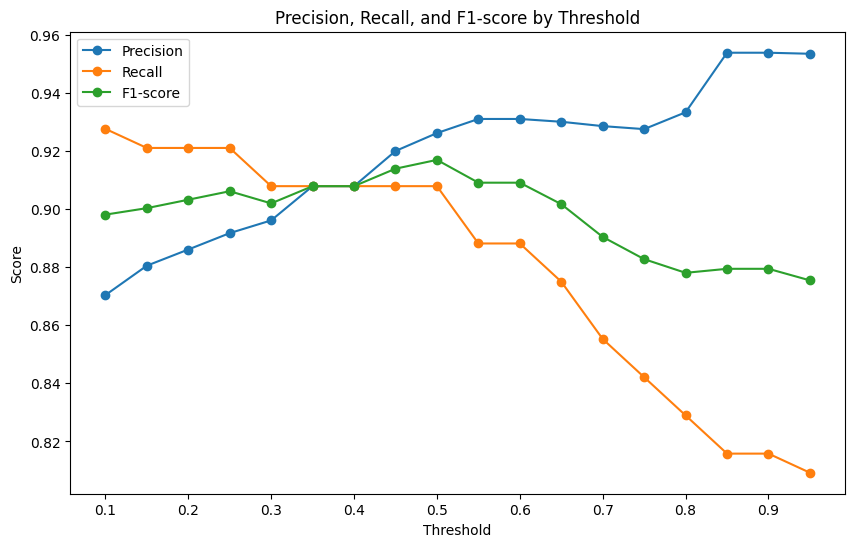

In [240]:
# 閾値ごとのPrecison・Recall・F1-scoreを可視化

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_summary_df['threshold'],
    threshold_summary_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_summary_df['threshold'],
    threshold_summary_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_summary_df['threshold'],
    threshold_summary_df['f1'],
    marker='o',
    label='F1-score'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score by Threshold')
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.legend()
plt.show()

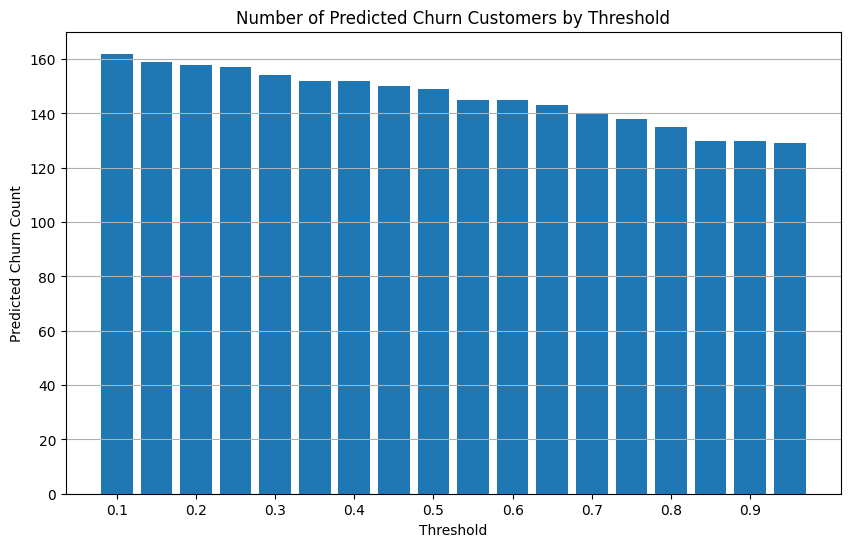

In [241]:
# 閾値ごとの施策対象者数を可視化
plt.figure(figsize=(10, 6))

plt.bar(
    threshold_summary_df['threshold'],
    threshold_summary_df['predicted_churn_count'],
    width=0.04
)

plt.xlabel('Threshold')
plt.ylabel('Predicted Churn Count')
plt.title('Number of Predicted Churn Customers by Threshold')
plt.xticks(np.round(np.arange(0.1, 1.0, 0.1), 1))
plt.grid(axis='y')
plt.show()

- 検証データを用いて、閾値を0.10から0.95まで変化させた場合のPrecision・Recall・F1-scoreを確認した。
- 閾値を低くするとRecallは高くなる一方で、Precisionは低下し、離脱顧客を広く拾う代わりに誤検出も増える傾向が見られた。
- 一方、閾値を高くするとPrecisionは上昇する一方で、Recallは低下し、施策対象の精度は高まるが見逃しも増える傾向が見られた。
- F1-scoreは閾値0.50で最大となり、Precisionは約92.6%、Recallは約90.8%、F1-scoreは約91.7%であった。
- 施策対象者数は、閾値0.10では162人、閾値0.50では149人、閾値0.95では129人となり、閾値を高くするほど減少した。

### 6.2 施策目的に応じた閾値の選定

ここでは、6.1で確認した閾値ごとのPrecision・Recall・F1-scoreと施策対象者数を踏まえて、本分析で採用する閾値を選定する。

離脱予測では、離脱顧客の見逃しを抑えることが重要である一方、施策対象を広げすぎるとクーポン配布や個別対応などのコストが増加する。

Recallを重視する場合は、より多くの離脱顧客を拾うために低めの閾値を選ぶことが考えられる。一方で、Precisionを重視する場合は、施策対象を確度の高い顧客に絞るために高めの閾値を選ぶことが考えられる。

本分析では、離脱顧客の見逃しと施策対象の精度のバランスを重視し、F1-scoreが最大となる閾値を採用する。

In [242]:
# F1-scoreが最大となる閾値とそのスコアを確認
best_f1_row = threshold_summary_df.loc[threshold_summary_df['f1'].idxmax()]
selected_threshold = best_f1_row['threshold']

print(f"F1-scoreが最大となる閾値: {selected_threshold:.2f}")
print(f"Accuracy: {best_f1_row['accuracy']:.3f}")
print(f"Precision: {best_f1_row['precision']:.3f}")
print(f"Recall: {best_f1_row['recall']:.3f}")
print(f"F1-score: {best_f1_row['f1']:.3f}")
print(f"予測離脱者数: {int(best_f1_row['predicted_churn_count'])}")
print(f"予測離脱者割合: {best_f1_row['predicted_churn_rate']:.3f}")

F1-scoreが最大となる閾値: 0.50
Accuracy: 0.972
Precision: 0.926
Recall: 0.908
F1-score: 0.917
予測離脱者数: 149
予測離脱者割合: 0.165


- 上記の通り、F1-scoreが最大となる閾値は0.50となった。

### 6.3 採用した閾値でテストデータを最終評価

ここでは検証データで選定した閾値を固定したうえで、これまでモデル学習・モデル比較・ハイパーパラメータ調整・閾値選定に使用していないテストデータに適用する。

あわせて混同行列を確認し、実際の離脱有無と予測結果の対応を確認する。

これにより、選定したモデルと閾値が未知データに対してどの程度の性能を示すかを最終確認する。

In [243]:
# テストデータに対する離脱確率を取得
test_proba = best_lgbm_pipeline.predict_proba(X_test)[:, 1]

# 採用した閾値で0/1に変換
y_test_pred_selected = (test_proba >= selected_threshold).astype(int)

# 評価指標を計算
test_accuracy = accuracy_score(y_test, y_test_pred_selected)
test_precision = precision_score(y_test, y_test_pred_selected, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_selected)
test_f1 = f1_score(y_test, y_test_pred_selected)
test_pr_auc = average_precision_score(y_test, test_proba)

print(f"Threshold: {selected_threshold:.2f}")
print(f"Accuracy : {test_accuracy:.3f}")
print(f"Precision: {test_precision:.3f}")
print(f"Recall   : {test_recall:.3f}")
print(f"F1-score : {test_f1:.3f}")
print(f"PR-AUC   : {test_pr_auc:.3f}")

Threshold: 0.50
Accuracy : 0.985
Precision: 0.983
Recall   : 0.926
F1-score : 0.954
PR-AUC   : 0.983


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [244]:
# 混同行列をDataFrame形式で確認
cm = confusion_matrix(y_test, y_test_pred_selected)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,933,3
Actual Churn=1,14,176


- 検証データで選定した閾値0.50を、テストデータに適用して最終評価を行った。
- テストデータにおける評価結果は、Accuracyが約98.5%、Precisionが約98.3%、Recallが約92.6%、F1-scoreが約95.4%、PR-AUCが約98.3%であった。
- 混同行列を確認すると、実際の離脱顧客190件のうち176件を正しく離脱と予測できており、False Negativeは14件であった。
- 一方で、実際には離脱していない顧客936件のうち、離脱と誤って予測した顧客は3件のみであり、False Positiveは非常に少なかった。
- 以上より、採用した閾値0.50は、離脱顧客の見逃しを一定程度抑えつつ、施策対象の精度も高く保てる閾値であると考えられる。
- ただし、非常に高い評価結果となっているため、実務で同様の精度が得られるとは限らない。
- 本データセットでは `Churn` の具体的な定義や各特徴量の取得時点が明記されていないため、最終章では本分析の限界として改めて整理する。

## 7. モデル解釈

前章までで、チューニング後のLightGBMモデルを用いて離脱予測を行い、閾値調整およびテストデータでの最終評価を行った。

本章では、構築したモデルがどの特徴量を重視して離脱予測を行っているかを確認する。

まず、LightGBMのFeature Importanceを用いて、モデル全体として重要度の高い特徴量を確認する。

そのうえで、後続のSHAP分析により、各特徴量が離脱予測にどの方向で影響しているかを確認する。

### 7.1 Feature Importance

ここでは、チューニング後のLightGBMモデルについて、GainベースのFeature Importanceを用いて、モデル上重要度の高い特徴量を確認する。

In [245]:
# 学習済みPipelineからLightGBMモデルを取得
lgbm_model_final = best_lgbm_pipeline.named_steps['model']

# GainベースのFeature Importanceを取得
importance_gain = lgbm_model_final.booster_.feature_importance(importance_type='gain')

# 前処理後の特徴量名を取得
feature_names = best_lgbm_pipeline.named_steps['preprocessor'].get_feature_names_out()

# DataFrame化し、上位20件を表示
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_gain': importance_gain
}).sort_values('importance_gain', ascending=False)

feature_importance_df.head(20)

,feature,importance_gain
0,num__Tenure,8696.960406
10,num__CashbackAmount,2725.413550
4,num__NumberOfAddress,1603.206484
1,num__WarehouseToHome,1504.258592
9,num__DaySinceLastOrder,1429.570237
5,num__Complain,1305.182462
6,num__OrderAmountHikeFromlastYear,988.214997
3,num__NumberOfDeviceRegistered,631.085143
32,cat__SatisfactionScore_1,602.631880
31,cat__MaritalStatus_Single,596.983061


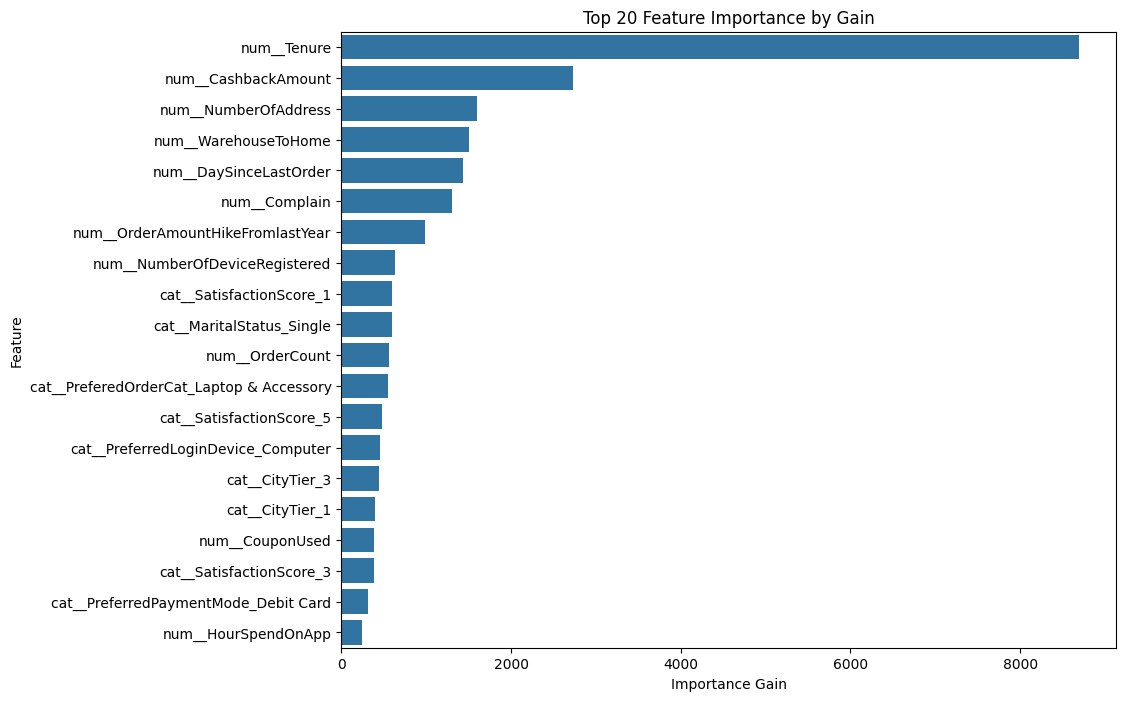

In [246]:
# Feature Importance上位20件を可視化
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance_df.head(20),
    x='importance_gain',
    y='feature'
)

plt.title('Top 20 Feature Importance by Gain')
plt.xlabel('Importance Gain')
plt.ylabel('Feature')
plt.show()

- Feature Importanceでは、`Tenure` が最も重要度の高い特徴量となった。
- `Tenure` はEDAでも利用開始初期の顧客ほど離脱率が高い傾向が見られており、モデル上でも重要な特徴量として確認できた。
- 次いで、`CashbackAmount`、`NumberOfAddress`、`WarehouseToHome`、`DaySinceLastOrder`、`Complain` などが上位に入った。
- 初期EDAで重点的に確認していなかった特徴量も上位に入っており、モデル解釈によって追加で注目すべき特徴量を把握できた。

### 7.2 SHAPによる特徴量の影響確認

Feature Importanceでは、モデルがどの特徴量を重視しているかを確認できた。

一方、Feature Importanceだけでは各特徴量が離脱確率を上げる方向に働いているのか、下げる方向に働いているのかまでは分からない。

そこで本節では、SHAPを用いて各特徴量が離脱予測に与える影響の方向性を確認する。

In [247]:
import shap

# 検証データを前処理
X_shap = best_lgbm_pipeline.named_steps['preprocessor'].transform(X_valid)

# DataFrame化
feature_names = best_lgbm_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_shap = pd.DataFrame(X_shap, columns=feature_names)

# SHAP値を計算
lgbm_model_final = best_lgbm_pipeline.named_steps['model']
explainer = shap.TreeExplainer(lgbm_model_final)
shap_values = explainer.shap_values(X_shap)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


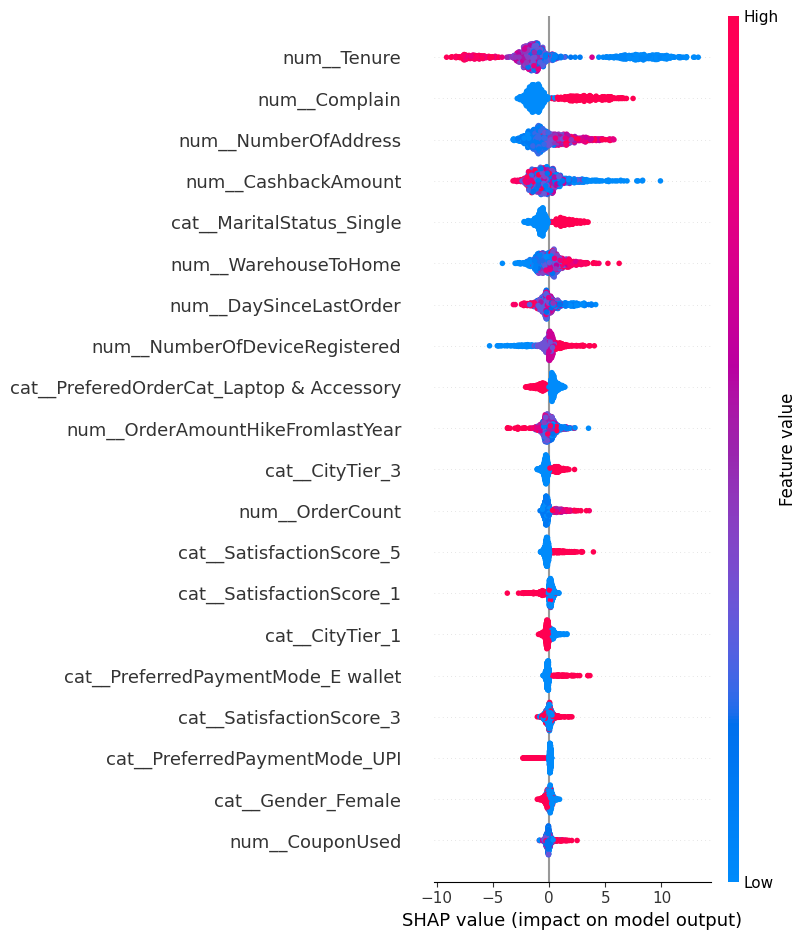

In [248]:
# SHAP summary plotを表示(上位20件)
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)

- SHAP summary plotを用いて、各特徴量が離脱予測に与える影響の方向性を確認した。
- SHAP値は予測ラベルの0/1そのものではなく、モデル出力に対する各特徴量の寄与度を表す。
- そのため、横軸の値は確率ではなく、右側にあるほど離脱予測を高める方向、左側にあるほど離脱予測を下げる方向に影響していると解釈する。
- `Tenure` は値が低い顧客ほど離脱予測を高める方向に影響しており、EDAで確認した「利用開始初期の顧客ほど離脱率が高い」という傾向と整合していた。
- `Complain` は、クレームありの顧客ほど離脱予測を高める方向に影響しており、こちらもEDAの結果と整合していた。
- `CashbackAmount` は、値が低い顧客ほど離脱予測を高める方向に影響している傾向が見られた。
- `NumberOfAddress` や `WarehouseToHome` も離脱予測に一定の影響を与えており、登録情報や配送条件も離脱リスクに関係している可能性がある。

## 8. 施策提案

前章では、Feature ImportanceとSHAPを用いて、モデルが重視している特徴量と、それぞれの特徴量が離脱予測に与える影響の方向性を確認した。

本章では、これらのモデル解釈結果を踏まえて、離脱リスクの高い顧客層を整理し、離脱防止に向けた施策を検討する。


### 8.1 離脱リスクの高い顧客層の整理

7章のモデル解釈結果を踏まえると、離脱リスクの高い顧客層として、以下のような特徴を持つ顧客が考えられる。

- **利用期間が短い顧客**
  - `Tenure` はFeature Importanceで最も重要度が高く、SHAPでも値が低い顧客ほど離脱予測を高める方向に影響していた。
  - EDAでも、利用開始初期の顧客ほど離脱率が高い傾向が見られた。
  - 利用開始初期の顧客は、サービスの価値を十分に体感する前に離脱する可能性がある。

- **クレームがある顧客**
  - `Complain` はSHAPで離脱予測を高める方向に影響していた。
  - EDAでも、クレームありの顧客はクレームなしの顧客より離脱率が高い傾向が見られた。
  - クレームがある顧客は、サービス体験に不満を持っている可能性があり、早期フォローが必要な顧客層と考えられる。

- **キャッシュバック金額が低い顧客**
  - `CashbackAmount` はFeature Importanceで上位に入り、SHAPでも値が低い顧客ほど離脱予測を高める方向に影響している傾向が見られた。
  - 還元や特典を十分に受けていない顧客は、サービス利用のメリットを感じにくい可能性がある。

- **配送条件に課題がある可能性のある顧客**
  - `WarehouseToHome` はFeature Importanceで上位に入り、SHAPでも離脱予測に一定の影響を与えていた。
  - 配送拠点から自宅までの距離が長い顧客は、配送リードタイムや配送体験の悪化によって離脱リスクが高まる可能性がある。

### 8.2 離脱防止施策の提案

8.1で整理した離脱リスクの高い顧客層に対して、以下のような離脱防止施策が考えられる。

- **利用開始初期顧客へのオンボーディング強化**
  - 対象：`Tenure` が短く、離脱予測確率が高い顧客。
  - 施策例：初回購入後のフォローメール、利用ガイド、初回限定クーポン、レコメンド商品の提示。
  - 目的：サービスの価値を早期に体感してもらい、利用開始初期の離脱を抑制する。

- **クレーム発生顧客への早期フォロー**
  - 対象：`Complain=1` で離脱予測確率が高い顧客。
  - 施策例：クレーム発生後のフォロー連絡、対応状況の確認、補償クーポンの付与、サポート品質の改善。
  - 目的：不満を放置せず、顧客体験を回復させることで、クレームをきっかけとした離脱を防止する。

- **還元・特典が少ない顧客への再購入促進**
  - 対象：`CashbackAmount` が低く、離脱予測確率が高い顧客。
  - 施策例：期間限定クーポン、ポイント還元キャンペーン、購入カテゴリに応じたパーソナライズドオファー。
  - 目的：金銭的メリットや再購入のきっかけを提供し、離脱前の再接点を作る。
  - 注意点：過度な値引きは利益率を悪化させるため、顧客単価や購入頻度を踏まえて対象を絞る必要がある。

- **配送条件に課題がある顧客への体験改善**
  - 対象：`WarehouseToHome` が大きく、離脱予測確率が高い顧客。
  - 施策例：配送予定日の明確化、配送状況通知、送料無料条件の調整、配送遅延時のフォロー。
  - 目的：配送に関する不満や不安を軽減し、購買体験の悪化による離脱を抑制する。

## 9. まとめ

本分析では、EC顧客データを用いて顧客が離脱するかどうかを予測する分類モデルを構築した。

EDAにより離脱傾向を把握したうえで、Logistic Regression と LightGBM を比較し、最終的に LightGBM を採用した。

その後、ハイパーパラメータ調整、閾値調整、テストデータでの最終評価、Feature Importance と SHAP によるモデル解釈を行い、最後に離脱防止施策を検討した。

### 9.1 分析結果のまとめ

- 本データは5,630件のEC顧客データであり、目的変数 `Churn` の離脱率は約16.8%であった。
- 離脱顧客が少ないクラス不均衡データであるため、Accuracyだけでなく、Precision、Recall、PR-AUCも重視して評価した。
- EDAでは、`Tenure` が短い顧客ほど離脱率が高い傾向が見られた。
- `Complain` では、クレームありの顧客の離脱率が約31.7%となり、クレームなしの顧客より高い傾向が見られた。
- Logistic Regression は、Recallが約80.9%となり、ベースラインモデルと比較して離脱顧客を検出できるようになった一方、Precisionは約47.3%にとどまった。
- LightGBM は、検証データにおいて Accuracyが約95.0%、Precisionが約82.0%、Recallが約90.1%、PR-AUCが約94.1%となり、Logistic Regressionを大きく上回る性能を示した。
- ハイパーパラメータ調整後のLightGBMは、検証データにおいて Accuracyが約97.2%、Precisionが約92.6%、Recallが約90.8%、PR-AUCが約96.8%となり、チューニング前より性能が改善した。
- 閾値調整では、検証データを用いて複数の閾値におけるPrecision・Recall・F1-scoreを確認し、F1-scoreが最大となる閾値0.50を採用した。
- 採用した閾値0.50をテストデータに適用した結果、Accuracyが約98.5%、Precisionが約98.3%、Recallが約92.6%、F1-scoreが約95.4%、PR-AUCが約98.3%となった。
- 混同行列では、実際の離脱顧客190件のうち176件を正しく離脱と予測できており、False Negativeは14件であった。
- Feature Importanceでは、`Tenure`、`CashbackAmount`、`NumberOfAddress`、`WarehouseToHome`、`DaySinceLastOrder`、`Complain` などが重要な特徴量として確認された。
- SHAPでは、`Tenure` が低い顧客、`Complain=1` の顧客、`CashbackAmount` が低い顧客などが、離脱予測を高める方向に影響していることを確認した。
- これらの結果を踏まえ、利用開始初期顧客へのオンボーディング強化、クレーム発生顧客への早期フォロー、還元・特典が少ない顧客への再購入促進、配送条件に課題がある顧客への体験改善を施策として提案した。

### 9.2 本分析の限界と今後の改善

- **目的変数の定義**
  - 本データセットでは、`Churn` は離脱フラグとして提供されているが、離脱の具体的な定義は明記されていない。
  - そのため、本分析では `Churn=1` を「離脱したと判定された顧客」として扱った。
  - 実務では、「一定期間購入がない顧客を離脱とみなす」のか、「退会・解約した顧客を離脱とみなす」のか等を明確にする必要がある。

- **特徴量の取得タイミング**
  - Data Dictでは、`Complain`、`CouponUsed`、`OrderCount`、`CashbackAmount` などが「last month」の情報として説明されている。
  - 一方で、その「last month」が `Churn` 判定より前の期間を指すのか、離脱判定と同時期または判定後の情報を含むのかは明記されていない。
  - そのため、実務では各特徴量が予測時点で利用可能な情報かどうかを確認する必要がある。
  - 予測時点より後にしか分からない情報が含まれている場合、データリークとなる可能性がある。
  - 今回のモデルは非常に高い評価結果となっているため、実務利用時には特徴量の取得時点を慎重に確認する必要がある。

- **評価方法**
  - 本データには明確な日付カラムがないため、本分析ではランダム分割で評価した。
  - 実務で日付情報が利用できる場合は、過去の顧客行動データで学習し、未来の離脱を予測する形で評価することが望ましい。

- **施策効果の検証**
  - 本分析では、Feature ImportanceやSHAPによるモデル解釈結果をもとに、離脱防止施策を提案した。
  - ただし、これらの施策はモデルの予測傾向に基づく仮説であり、実際の効果を直接確認したものではない。
  - 実際に施策を実行する場合は、対象者数、顧客単価、施策コスト、期待される離脱抑制効果等を確認する必要がある。

- **今後の改善**
  - 今後は、離脱定義の明確化、特徴量取得時点の整理、時系列を考慮した評価設計を行うことで、より実務に近い分析に改善できる。
  - また、実務では施策コストや顧客単価も考慮し、費用対効果の高い顧客に優先して施策を行うことが重要であると考えられる。